## **Подготовка к работе с данными**

Импорт всех необходимых библиотек

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from datetime import datetime
import plotly.express as px
from dotenv import load_dotenv
import os

## **Запросы к API**

In [4]:
load_dotenv()

API_URL = os.getenv('API_URL')
DATE_BEGIN = os.getenv('DATE_BEGIN')
DATE_END = os.getenv('DATE_END')

In [5]:
vis_api = requests.get(f"{API_URL}/visits?begin={DATE_BEGIN}&end={DATE_END}")
data_vis = vis_api.json()
df_visits = pd.DataFrame(data_vis)
df_visits.head(300000)

,visit_id,platform,user_agent,datetime
0,1de9ea66-70d3-4a1f-8735-df5ef7697fb9,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,2023-03-01T10:36:22
1,f149f542-e935-4870-9734-6b4501eaf614,web,Mozilla/5.0 (Windows NT 10.0; WOW64; Trident/7...,2023-03-01T06:25:00
2,08f0ebd4-950c-4dd9-8e97-b5bdf073eed1,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_11_2...,2023-03-01T10:26:13
3,19322fed-157c-49c6-b16e-2d5cabeb9592,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,2023-03-01T12:33:06
4,04762a22-3c9f-40c9-9ac9-6628c4381836,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,2023-03-01T01:38:35
...,...,...,...,...
263454,6d2e2f5b-970b-4dfe-8f57-25711a5b2a5d,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,2023-08-29T10:43:29
263455,1d91535e-d984-4f76-bbaa-c14c0fd4f2e2,web,Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:109...,2023-08-29T19:29:16
263456,f2496721-7126-430d-976e-777a6cdccb4f,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,2023-08-29T12:51:11
263457,f2496721-7126-430d-976e-777a6cdccb4f,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,2023-08-29T21:45:08


In [6]:
reg_api = requests.get(f"{API_URL}/registrations?begin={DATE_BEGIN}&end={DATE_END}")
data_reg = reg_api.json()
df_registrations = pd.DataFrame(data_reg)
df_registrations.head(300000)

,datetime,user_id,email,platform,registration_type
0,2023-03-01T07:40:13,2e0f6bb8-b029-4f45-a786-2b53990d37f1,ebyrd@example.org,web,google
1,2023-03-01T13:14:00,f007f97c-9d8b-48b5-af08-119bb8f6d9b6,knightgerald@example.org,web,email
2,2023-03-01T03:05:50,24ff46ae-32b3-4a74-8f27-7cf0b8f32f15,cherylthompson@example.com,web,apple
3,2023-03-01T00:04:47,3e9914e1-5d73-4c23-b25d-b59a3aeb2b60,halldavid@example.org,web,email
4,2023-03-01T18:31:52,27f875fc-f8ce-4aeb-8722-0ecb283d0760,denise86@example.net,web,google
...,...,...,...,...,...
21831,2023-08-31T07:32:08,a94b4a28-f25c-433c-b4ef-85af7d5b0c11,ikelley@example.net,ios,apple
21832,2023-08-31T23:25:50,fc709c6b-528b-40d8-8980-c2c278e5a628,brittanycox@example.net,ios,apple
21833,2023-08-31T19:29:18,11e32805-7571-4108-8e50-e211d051bf7e,aryan@example.net,ios,apple
21834,2023-08-31T19:38:54,bce7b818-768b-434a-b6af-573cd60bff7f,emartinez@example.net,ios,email


## **Расчет метрик**

Обработка визитов (фильтрация ботов и дубликатов)

In [7]:
df_visits['datetime'] = pd.to_datetime(df_visits['datetime'])
df_visits_no_bots = df_visits[~df_visits['user_agent'].str.contains('bot', case=False, na=False)]
df_visits_last = df_visits_no_bots.sort_values(['visit_id', 'datetime']).drop_duplicates('visit_id', keep='last')
df_visits_last['date_group'] = df_visits_last['datetime'].dt.date
df_visits_last.head()

,visit_id,platform,user_agent,datetime,date_group
135241,000012d3-f8c7-4257-8999-ad622b703492,android,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,2023-06-06 20:32:30,2023-06-06
236542,0000164b-36eb-409a-8ab4-4acc25e5f3de,web,Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:109...,2023-08-16 11:36:01,2023-08-16
171104,0000190e-e494-4fe1-876f-0dc2b4e1be1c,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,2023-07-02 18:49:04,2023-07-02
258646,000063a2-6a6c-466a-b7e5-781568668a6b,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,2023-08-29 20:14:40,2023-08-29
170245,0000b829-7f90-4a38-b831-9b314ecfd8b5,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,2023-07-02 07:20:46,2023-07-02


Обработка регистраций 

In [8]:
df_registrations['datetime'] = pd.to_datetime(df_registrations['datetime'])
df_registrations['date_group'] = df_registrations['datetime'].dt.date
df_registrations.head()

,datetime,user_id,email,platform,registration_type,date_group
0,2023-03-01 07:40:13,2e0f6bb8-b029-4f45-a786-2b53990d37f1,ebyrd@example.org,web,google,2023-03-01
1,2023-03-01 13:14:00,f007f97c-9d8b-48b5-af08-119bb8f6d9b6,knightgerald@example.org,web,email,2023-03-01
2,2023-03-01 03:05:50,24ff46ae-32b3-4a74-8f27-7cf0b8f32f15,cherylthompson@example.com,web,apple,2023-03-01
3,2023-03-01 00:04:47,3e9914e1-5d73-4c23-b25d-b59a3aeb2b60,halldavid@example.org,web,email,2023-03-01
4,2023-03-01 18:31:52,27f875fc-f8ce-4aeb-8722-0ecb283d0760,denise86@example.net,web,google,2023-03-01


Группировка визитов по дате и платформе

In [9]:
visits_grouped = df_visits_last.groupby(['date_group', 'platform']).size().reset_index(name='visits')
visits_grouped = visits_grouped[visits_grouped['platform'].isin(['web', 'ios', 'android'])]
visits_grouped.head(552)

,date_group,platform,visits
0,2023-03-01,android,75
1,2023-03-01,ios,22
2,2023-03-01,web,279
3,2023-03-02,android,67
4,2023-03-02,ios,31
...,...,...,...
547,2023-08-30,ios,66
548,2023-08-30,web,1227
549,2023-08-31,android,57
550,2023-08-31,ios,50


Группировка регистраций по дате и платформе

In [10]:
regs_grouped = df_registrations.groupby(['date_group', 'platform']).size().reset_index(name='registrations')
regs_grouped = regs_grouped[regs_grouped['platform'].isin(['web', 'ios', 'android'])]
regs_grouped.head(552)

,date_group,platform,registrations
0,2023-03-01,android,61
1,2023-03-01,ios,18
2,2023-03-01,web,8
3,2023-03-02,android,59
4,2023-03-02,ios,24
...,...,...,...
547,2023-08-30,ios,40
548,2023-08-30,web,34
549,2023-08-31,android,42
550,2023-08-31,ios,36


Объединение и расчет конверсии

In [11]:
conversion_df = pd.merge(visits_grouped, regs_grouped, on=['date_group', 'platform'], how='left')
conversion_df['registrations'] = conversion_df['registrations'].fillna(0).astype(int)
conversion_df['conversion'] = (conversion_df['registrations'] / conversion_df['visits'] * 100).round(2)

Сортировка по дате

In [12]:
conversion_df = conversion_df.sort_values('date_group')

Сохранение в JSON

In [23]:
conversion_df.to_json('./conversion.json')

Вывод результата

In [24]:
conversion_df.head(552)

,date_group,platform,visits,registrations,conversion
0,2023-03-01,android,75,61,81.33
1,2023-03-01,ios,22,18,81.82
2,2023-03-01,web,279,8,2.87
3,2023-03-02,android,67,59,88.06
4,2023-03-02,ios,31,24,77.42
...,...,...,...,...,...
546,2023-08-30,android,35,27,77.14
548,2023-08-30,web,1227,34,2.77
550,2023-08-31,ios,50,36,72.00
549,2023-08-31,android,57,42,73.68


## **Добавление рекламы**

Загрузка данных о рекламе

In [15]:
ads_df = pd.read_csv('./ads.csv')
ads_df.head(160)

,date,utm_source,utm_medium,utm_campaign,cost
0,2023-03-01T10:54:41,google,cpc,advanced_algorithms_series,212
1,2023-03-02T10:32:35,google,cpc,advanced_algorithms_series,252
2,2023-03-03T19:21:40,google,cpc,advanced_algorithms_series,202
3,2023-03-04T17:52:04,google,cpc,advanced_algorithms_series,223
4,2023-03-05T05:35:13,google,cpc,advanced_algorithms_series,265
...,...,...,...,...,...
154,2023-09-13T05:34:02,vk,social,intro_to_python_course,277
155,2023-09-14T18:25:13,vk,social,intro_to_python_course,221
156,2023-09-15T15:35:47,vk,social,intro_to_python_course,175
157,2023-09-16T05:30:26,vk,social,intro_to_python_course,224


Подготовка данных о рекламе

In [16]:
ads_df['date'] = pd.to_datetime(ads_df['date'])
ads_df['date_group'] = ads_df['date'].dt.date
daily_cost = ads_df.groupby('date_group')['cost'].sum().reset_index()
daily_cost = daily_cost.rename(columns={'cost': 'total_daily_cost'})
campaigns_detail = ads_df[['date_group', 'utm_campaign', 'cost']].copy()
campaigns_daily = ads_df.groupby(['date_group', 'utm_campaign'])['cost'].sum().reset_index()
campaigns_daily = campaigns_daily.rename(columns={'cost': 'campaign_daily_cost'})
campaigns_daily.head(160)

,date_group,utm_campaign,campaign_daily_cost
0,2023-03-01,advanced_algorithms_series,212
1,2023-03-02,advanced_algorithms_series,252
2,2023-03-03,advanced_algorithms_series,202
3,2023-03-04,advanced_algorithms_series,223
4,2023-03-05,advanced_algorithms_series,265
...,...,...,...
154,2023-09-13,intro_to_python_course,277
155,2023-09-14,intro_to_python_course,221
156,2023-09-15,intro_to_python_course,175
157,2023-09-16,intro_to_python_course,224


**Объединение с рекламными данными**

In [17]:
ads_conversion_df = pd.merge(conversion_df, campaigns_daily, on='date_group', how='left')
ads_conversion_df = ads_conversion_df.rename(columns={'campaign_daily_cost': 'cost'})
ads_conversion_df.head(552)

,date_group,platform,visits,registrations,conversion,utm_campaign,cost
0,2023-03-01,android,75,61,81.33,advanced_algorithms_series,212.0
1,2023-03-01,ios,22,18,81.82,advanced_algorithms_series,212.0
2,2023-03-01,web,279,8,2.87,advanced_algorithms_series,212.0
3,2023-03-02,android,67,59,88.06,advanced_algorithms_series,252.0
4,2023-03-02,ios,31,24,77.42,advanced_algorithms_series,252.0
...,...,...,...,...,...,...,...
547,2023-08-30,android,35,27,77.14,intro_to_python_course,109.0
548,2023-08-30,web,1227,34,2.77,intro_to_python_course,109.0
549,2023-08-31,ios,50,36,72.00,intro_to_python_course,215.0
550,2023-08-31,android,57,42,73.68,intro_to_python_course,215.0


Заполнение пропусков

In [18]:
ads_conversion_df['cost'] = ads_conversion_df['cost'].fillna(0).astype(int)
ads_conversion_df['utm_campaign'] = ads_conversion_df['utm_campaign'].fillna('none')

Сортировка по дате

In [19]:
ads_conversion_df = ads_conversion_df.sort_values('date_group')

Сохранение в JSON

In [20]:
ads_conversion_df.to_json('./ads.json')

Вывод результата

In [21]:
ads_conversion_df.head(552)

,date_group,platform,visits,registrations,conversion,utm_campaign,cost
0,2023-03-01,android,75,61,81.33,advanced_algorithms_series,212
1,2023-03-01,ios,22,18,81.82,advanced_algorithms_series,212
2,2023-03-01,web,279,8,2.87,advanced_algorithms_series,212
3,2023-03-02,android,67,59,88.06,advanced_algorithms_series,252
4,2023-03-02,ios,31,24,77.42,advanced_algorithms_series,252
...,...,...,...,...,...,...,...
546,2023-08-30,ios,66,40,60.61,intro_to_python_course,109
548,2023-08-30,web,1227,34,2.77,intro_to_python_course,109
550,2023-08-31,android,57,42,73.68,intro_to_python_course,215
549,2023-08-31,ios,50,36,72.00,intro_to_python_course,215


## **Визуализация**

Создание папки для графиков

In [20]:
os.makedirs('./charts', exist_ok=True)

Подготовка DataFrame к визуализации

In [21]:
df_visual = ads_conversion_df.copy()
df_visual['date_week'] = pd.to_datetime(df_visual['date_group'])
df_visual['date_week'] = df_visual['date_week'].dt.to_period('W').dt.start_time.dt.date
df_visual = df_visual.groupby(['date_week'])[['visits', 'registrations', 'cost']].sum().reset_index()
df_visual['conversion'] = (df_visual['registrations'] / df_visual['visits'] * 100).round(2)
df_visual.head()

,date_week,visits,registrations,cost,conversion
0,2023-02-27,3026,574,3462,18.97
1,2023-03-06,8615,1184,3516,13.74
2,2023-03-13,5215,829,1494,15.90
3,2023-03-20,3950,664,1773,16.81
4,2023-03-27,4958,856,3861,17.27


**Итоговые визиты**

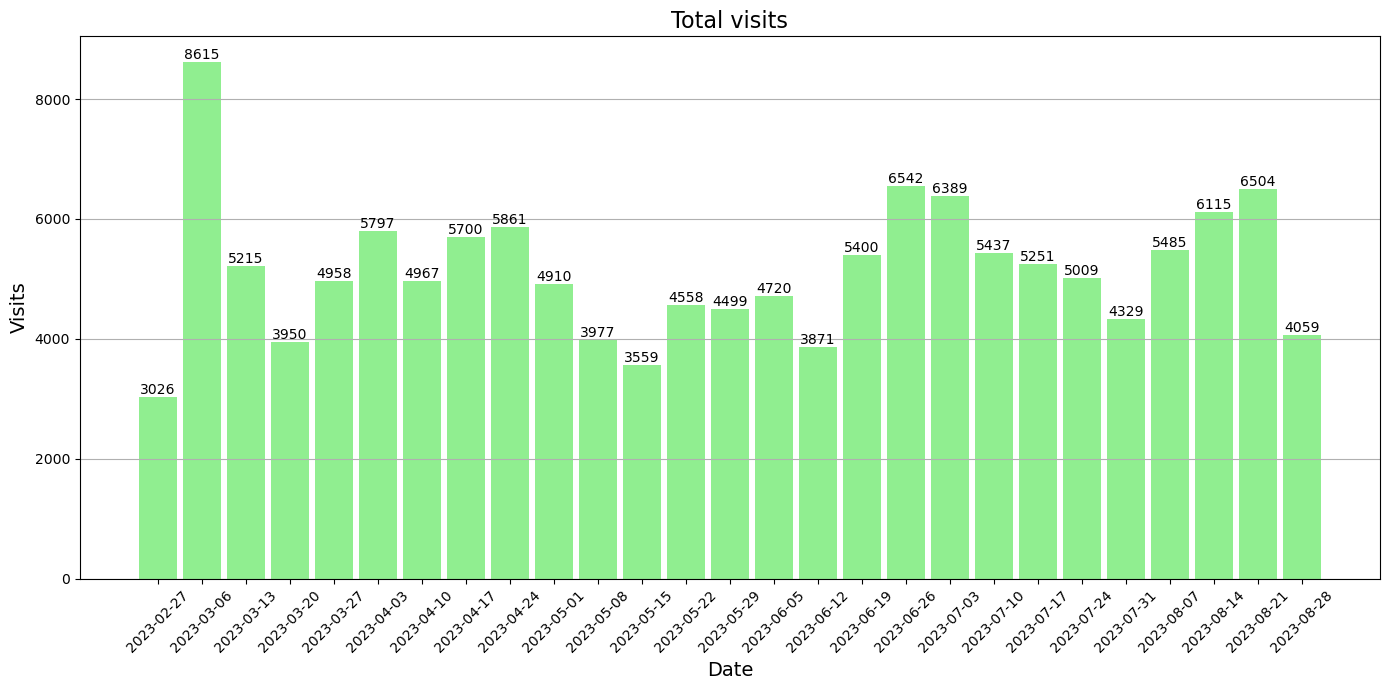

In [27]:
fig, ax = plt.subplots(figsize=(14,7))
bars = plt.bar(x='date_week', height='visits', data=df_visual, color='lightgreen', width=6)
ax.bar_label(bars)
plt.title('Total visits', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Visits', fontsize=14)
plt.xticks(df_visual['date_week'], rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig(f"./charts/Total_visits.png")
plt.show()

Подготовка DataFrame к визуализации

In [22]:
df_visual_platform = ads_conversion_df.copy()
df_visual_platform['date_week'] = pd.to_datetime(df_visual_platform['date_group'])
df_visual_platform['date_week'] = df_visual_platform['date_week'].dt.to_period('W').dt.start_time.dt.date
df_visual_platform = df_visual_platform.groupby(['date_week', 'platform'])[['visits', 'registrations']].sum().reset_index()
df_visual_platform['conversion'] = (df_visual_platform['registrations'] / df_visual_platform['visits'] * 100).round(2)
df_visual_platform.head()

,date_week,platform,visits,registrations,conversion
0,2023-02-27,android,328,273,83.23
1,2023-02-27,ios,177,132,74.58
2,2023-02-27,web,2521,169,6.70
3,2023-03-06,android,733,522,71.21
4,2023-03-06,ios,296,214,72.30


**Итоговые визиты по платформам**

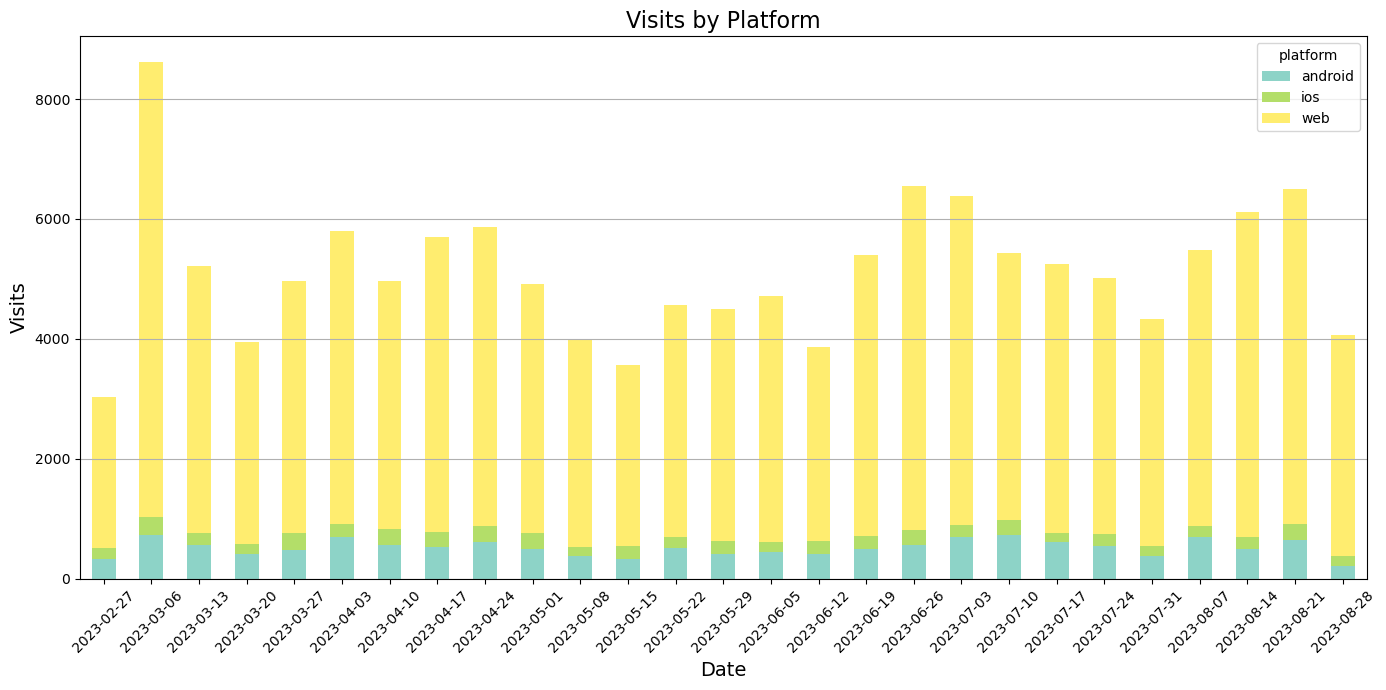

In [23]:
fig, ax = plt.subplots(figsize=(14,7))
df_visits_pivot = df_visual_platform.pivot_table(index='date_week', columns='platform', values='visits')
df_visits_pivot.plot(kind='bar', stacked=True, ax=ax, colormap='Set3')
plt.title('Visits by Platform', fontsize=16)
plt.xlabel('Date',fontsize=14)
plt.ylabel('Visits',fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig(f"./charts/Total_visits_platform.png")
plt.show()

**Итоговые регистрации**

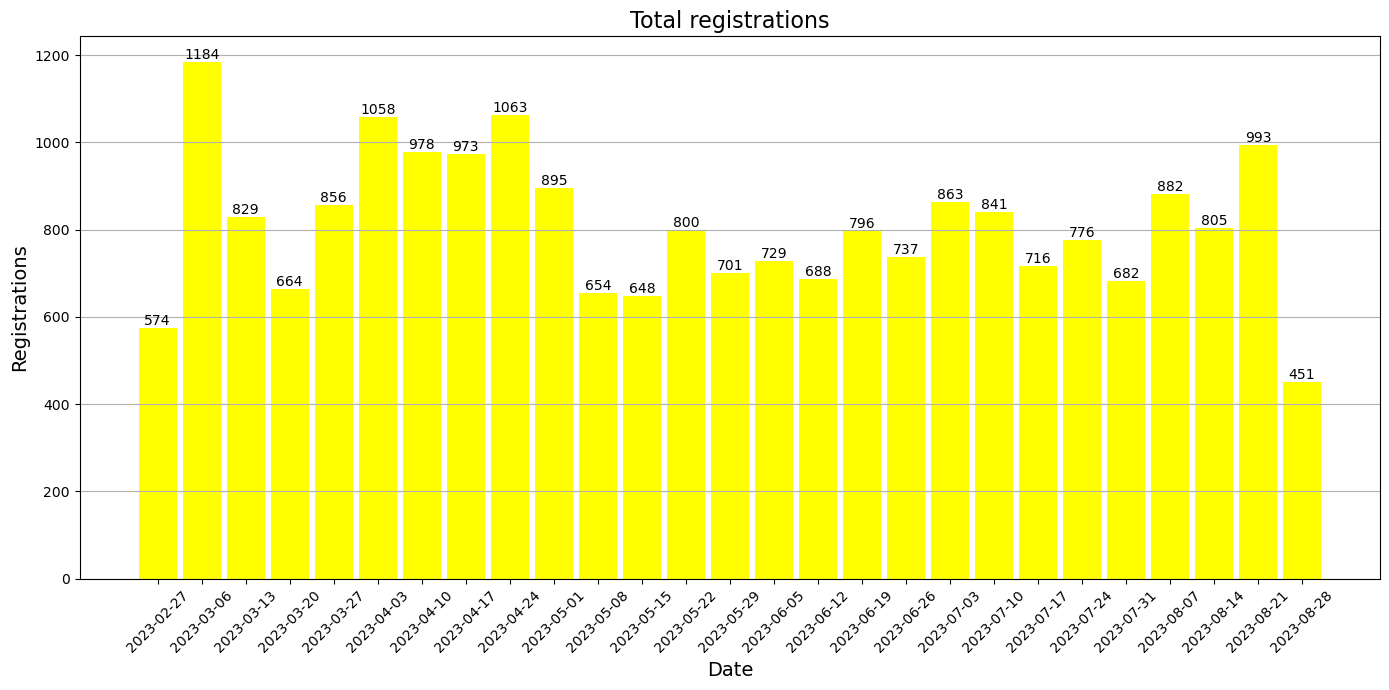

In [24]:
fig, ax = plt.subplots(figsize=(14,7))
bars = plt.bar(x='date_week', height='registrations', data=df_visual, color='yellow', width=6)
ax.bar_label(bars)
plt.title('Total registrations', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Registrations', fontsize=14)
plt.xticks(df_visual['date_week'], rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig(f"./Total_registrations.png")
plt.show()

**Итоговые регистрации по платформам**

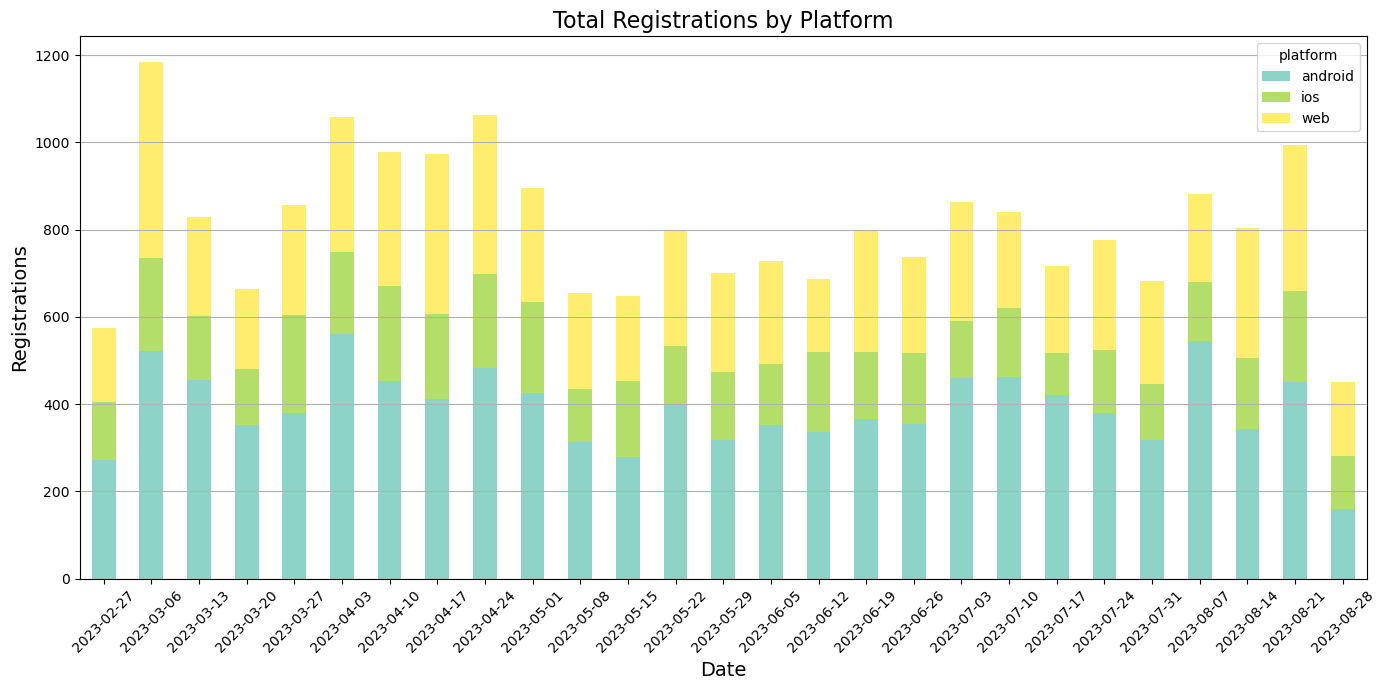

In [25]:
fig, ax = plt.subplots(figsize=(14,7))
df_regs_pivot = df_visual_platform.pivot_table(index='date_week', columns='platform', values='registrations')
df_regs_pivot.plot(kind='bar', stacked=True, ax=ax, colormap='Set3')
plt.title('Total Registrations by Platform', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Registrations', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig(f"./charts/Total_registrations_by_platform.png")
plt.show()

**Конверсия по платформам**

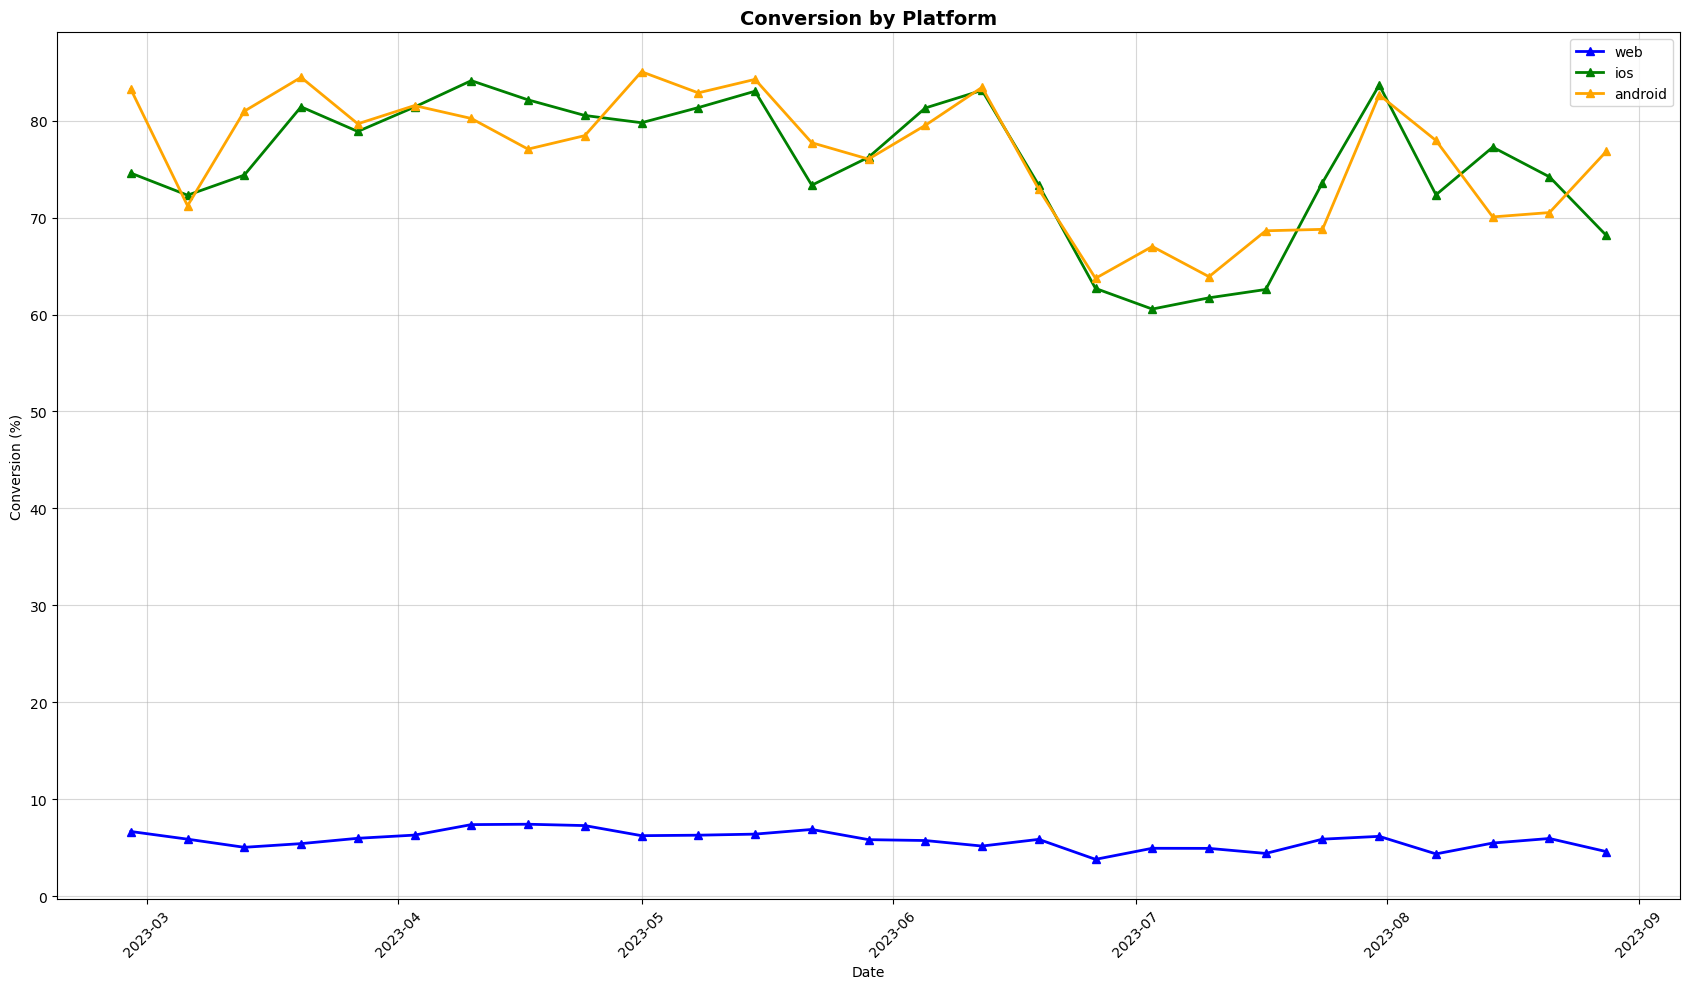

In [26]:
colors = {'web': 'blue', 'ios': 'green', 'android': 'orange'}

plt.figure(figsize=(17, 10))
for platform in ['web', 'ios', 'android']:
    platform_data = df_visual_platform[df_visual_platform['platform'] == platform]
    if not platform_data.empty:
        plt.plot(platform_data['date_week'], platform_data['conversion'], 
                marker='^', label=platform, linewidth=2, color=colors[platform])
plt.title('Conversion by Platform', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Conversion (%)')
plt.legend()
plt.grid(True, alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('./charts/Conversion_by_platforms.png')
plt.show()

**Средняя конверсия**

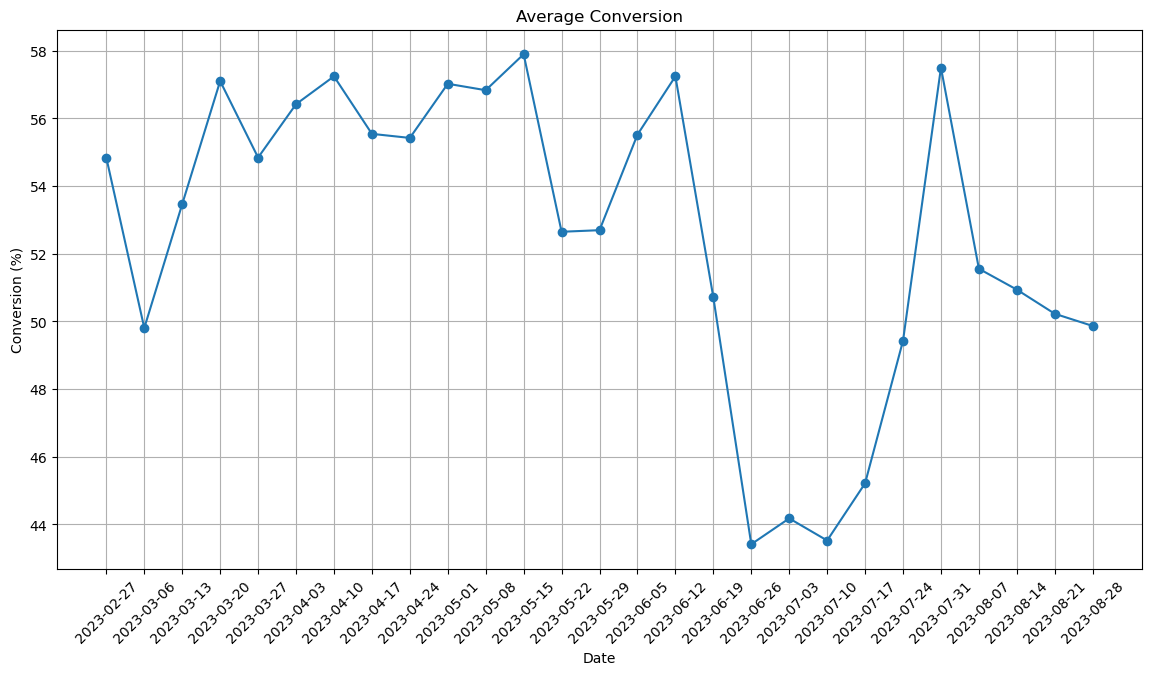

In [34]:
avg_conversion = df_visual_platform.groupby('date_week')['conversion'].mean().plot(figsize=(14,7), style='o-', grid=True)
plt.title('Average Conversion')
plt.xlabel('Date')
plt.ylabel('Conversion (%)')
plt.xticks(df_visual_platform['date_week'].unique(), rotation=45)
plt.savefig(f"./charts/Avg_conversion.png")
plt.show()

**Стоимости реклам**

In [35]:
df_cost = ads_conversion_df.copy()
df_cost['date_week'] = pd.to_datetime(df_cost['date_group'])
df_cost['date_week'] = df_cost['date_week'].dt.to_period('W').dt.start_time.dt.date
df_cost = df_cost.groupby(['date_week'])['cost'].sum().reset_index()

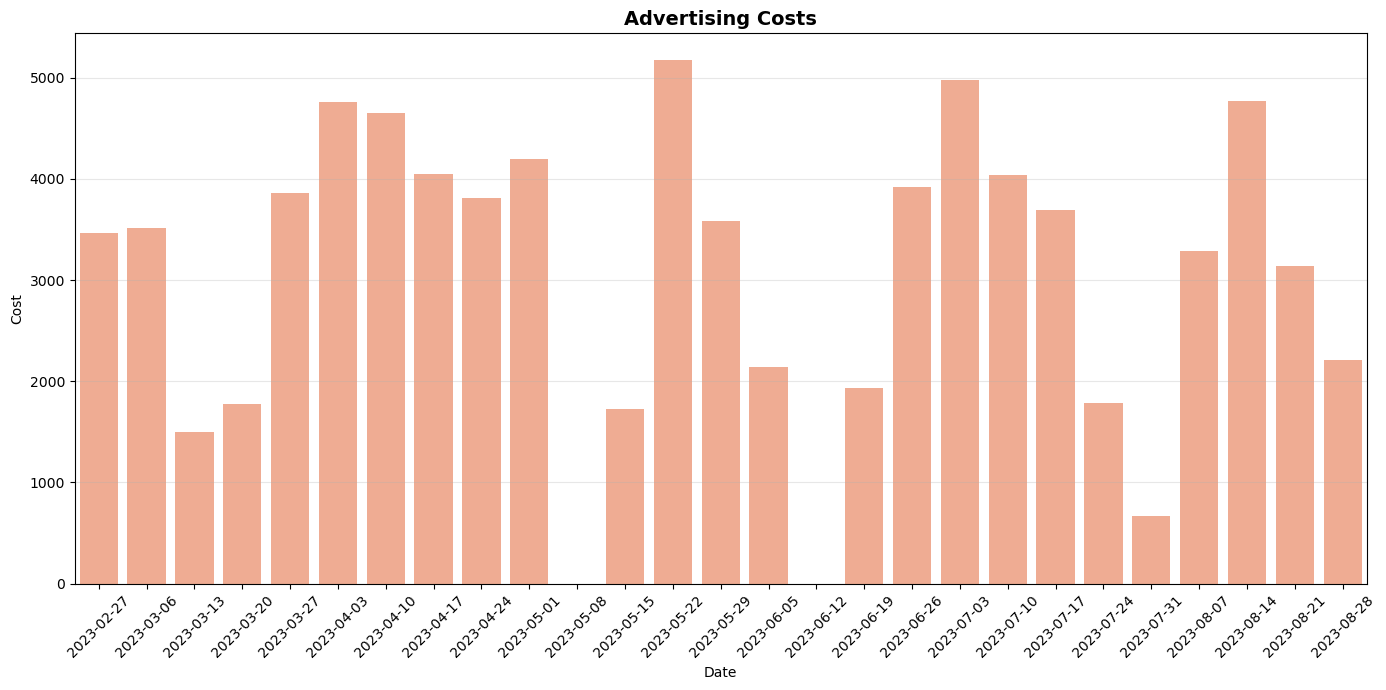

In [36]:
plt.figure(figsize=(14, 7))
sns.barplot(data=df_cost, x='date_week', y='cost', color='coral', alpha=0.7)
plt.title('Advertising Costs', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Cost')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('./charts/Ads_cost.png')
plt.show()

**Визиты и регистрации за весь период с цветовым выделением рекламной кампании**

Подготовка данных к визуализации

In [32]:
from matplotlib.dates import DateFormatter
import matplotlib.patches as mpatches

In [33]:
df_campaign_periods = ads_conversion_df.copy()
df_campaign_periods = df_campaign_periods.groupby(['utm_campaign']).agg(
    start=('date_group', 'min'), 
    end=('date_group', 'max')
).reset_index()
df_campaign_periods = df_campaign_periods.sort_values('start').reset_index(drop=True)
df_campaign_periods.head(6)

,utm_campaign,start,end
0,advanced_algorithms_series,2023-03-01,2023-03-15
1,none,2023-03-16,2023-08-05
2,virtual_reality_workshop,2023-03-25,2023-05-06
3,ui_ux_design_drive,2023-05-19,2023-06-09
4,women_in_tech_symposium,2023-06-21,2023-07-26
5,intro_to_python_course,2023-08-06,2023-08-31


In [34]:
daily_data = ads_conversion_df.copy()
daily_data = daily_data.groupby('date_group').agg({'visits': 'sum', 'registrations': 'sum'}).reset_index()
daily_data.head(184)

,date_group,visits,registrations
0,2023-03-01,376,87
1,2023-03-02,613,106
2,2023-03-03,683,107
3,2023-03-04,647,159
4,2023-03-05,707,115
...,...,...,...
179,2023-08-27,795,88
180,2023-08-28,635,83
181,2023-08-29,1268,143
182,2023-08-30,1328,101


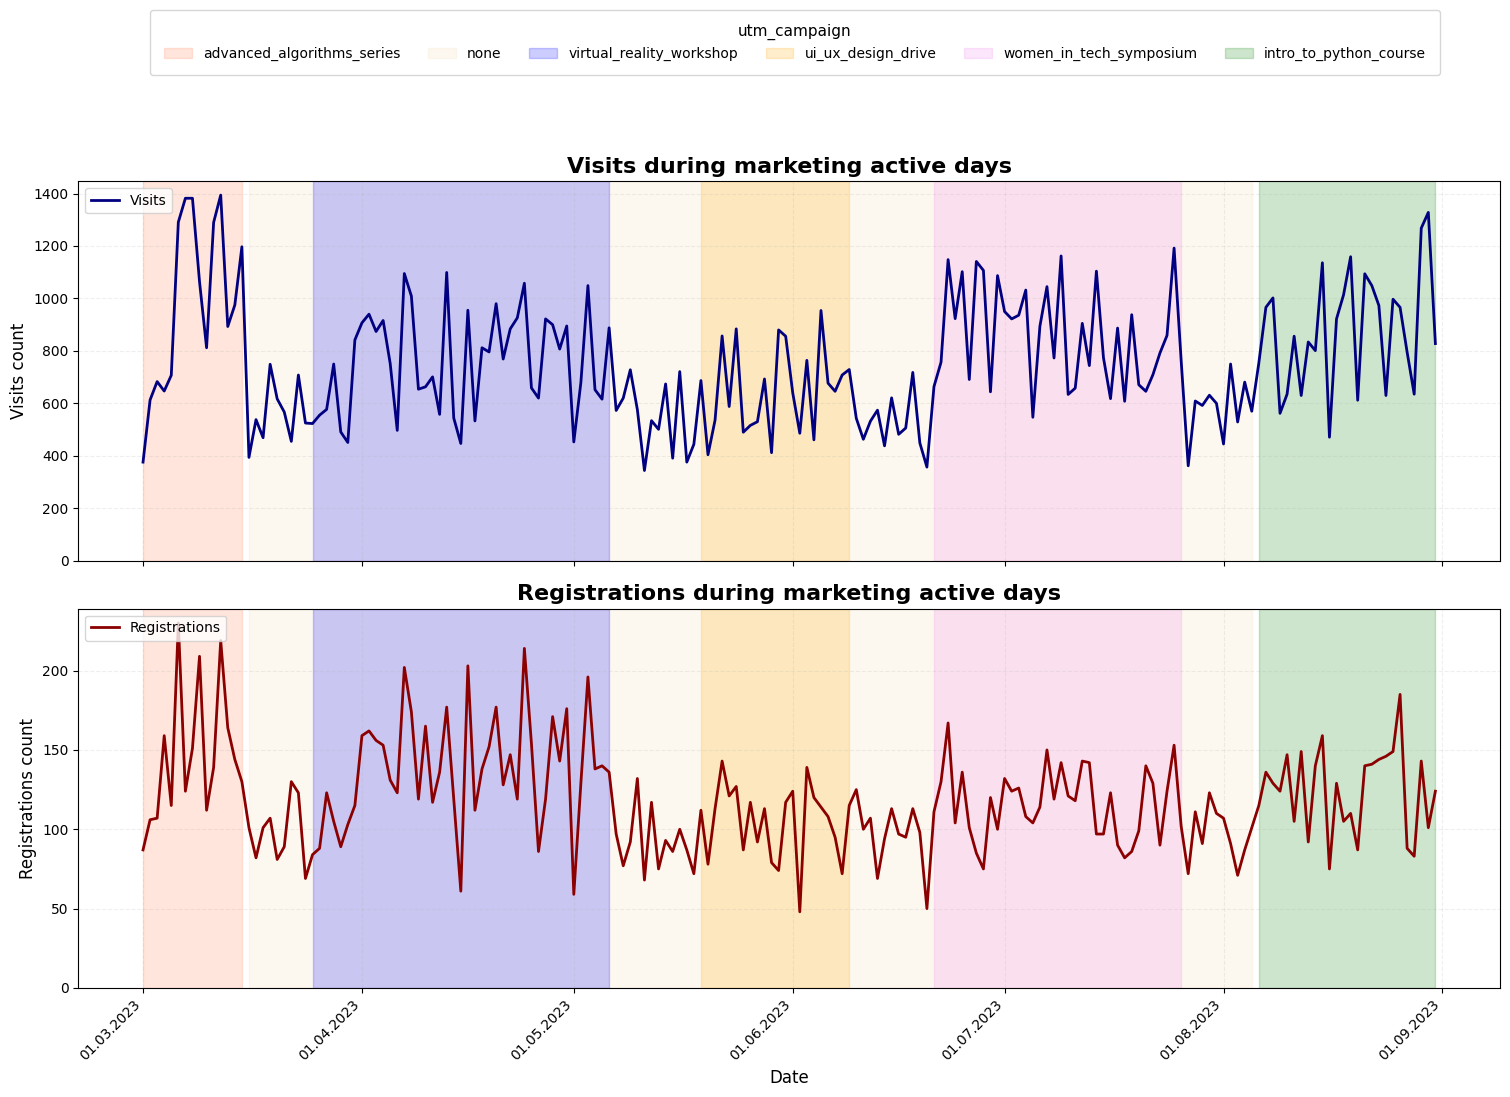

In [35]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
colors = ['coral', 'wheat', 'blue', 'orange', 'violet', 'green']

ax1.plot(daily_data['date_group'], daily_data['visits'], 
         linewidth=2, color='navy', label='Visits')

ax2.plot(daily_data['date_group'], daily_data['registrations'], 
         linewidth=2, color='darkred', label='Registrations')

for i, row in df_campaign_periods.iterrows():
    color_idx = i % len(colors)
    ax1.axvspan(row['start'], row['end'], color=colors[color_idx], alpha=0.2)
    ax2.axvspan(row['start'], row['end'], color=colors[color_idx], alpha=0.2)

ax1.set_title('Visits during marketing active days', fontsize=16, fontweight='bold')
ax1.set_ylabel('Visits count', fontsize=12)
ax1.grid(True, alpha=0.2, linestyle='--')
ax1.legend(loc='upper left')
ax1.set_ylim(bottom=0)

ax2.set_title('Registrations during marketing active days', fontsize=16, fontweight='bold')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Registrations count', fontsize=12)
ax2.grid(True, alpha=0.2, linestyle='--')
ax2.legend(loc='upper left')
ax2.set_ylim(bottom=0)

date_form = DateFormatter("%d.%m.%Y")
ax2.xaxis.set_major_formatter(date_form)
fig.autofmt_xdate(rotation=45)

legend_elements = []
for i, row in df_campaign_periods.iterrows():
    color_idx = i % len(colors)
    legend_elements.append(mpatches.Patch(color=colors[color_idx], alpha=0.2, label=row['utm_campaign']))

fig.legend(handles=legend_elements, title='utm_campaign',
           bbox_to_anchor=(0.5, 1.02),
           loc='lower center',
           ncol=len(legend_elements),
           fontsize=10,
           title_fontsize=11,
           frameon=True,
           fancybox=True,
           borderpad=1)

plt.tight_layout(rect=[0, 0, 0.95, 0.96])
plt.savefig(f"./charts/Visits_and_registrations_chart.png")
plt.show()

## **Для презентации**

In [43]:
campaign_conversion = ads_conversion_df[ads_conversion_df['utm_campaign'] != 'none'].copy()
campaign_stats = campaign_conversion.groupby('utm_campaign').agg({
    'visits': 'sum',
    'registrations': 'sum'
}).reset_index()
campaign_stats['conversion'] = (campaign_stats['registrations'] / campaign_stats['visits'] * 100).round(1)
start_dates = campaign_conversion.groupby('utm_campaign')['date_group'].min().reset_index()
start_dates.columns = ['utm_campaign', 'start']
campaign_stats = campaign_stats.merge(start_dates, on='utm_campaign')
campaign_stats = campaign_stats.sort_values('start')
campaign_stats[['utm_campaign', 'visits', 'registrations', 'conversion']].head()

,utm_campaign,visits,registrations,conversion
0,advanced_algorithms_series,14706,2196,14.9
3,virtual_reality_workshop,32698,5898,18.0
2,ui_ux_design_drive,14398,2308,16.0
4,women_in_tech_symposium,31028,4184,13.5
1,intro_to_python_course,22917,3246,14.2


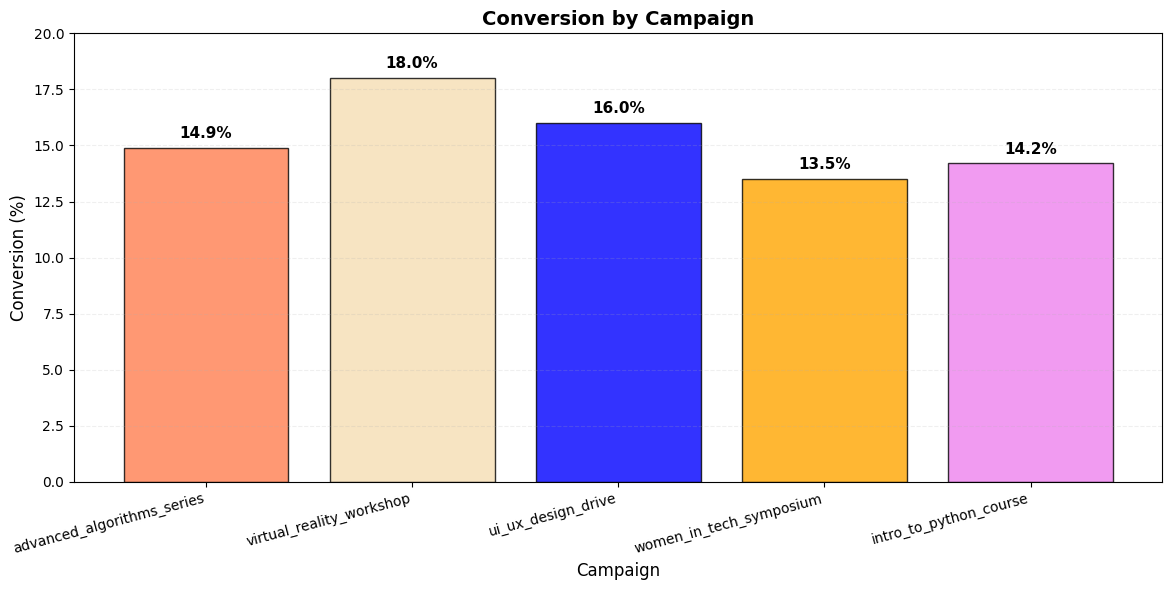

In [46]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['coral', 'wheat', 'blue', 'orange', 'violet']
campaign_stats['color'] = colors[:len(campaign_stats)]

bars = ax.bar(
    campaign_stats['utm_campaign'],
    campaign_stats['conversion'],
    color=campaign_stats['color'],
    alpha=0.8,
    edgecolor='black',
    linewidth=1
)

for bar, val in zip(bars, campaign_stats['conversion']):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{val}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(0, 20)
ax.set_ylabel('Conversion (%)', fontsize=12)
ax.set_xlabel('Campaign', fontsize=12)
ax.set_title('Conversion by Campaign', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.2, linestyle='--')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('./charts/conversion_by_campaign.png')
plt.show()